# Principio fondamentale del calcolo combinatorio

Lo so che può sembrare impossibile, ma in alcuni casi Batman ha scelto
di indossare dei costumi molto più sgargianti rispetto a quello grigio
dei fumetti originali e a quello nero dei film più recenti. Per esempio,
nel numero 241 di _Detective Comics_ l'uomo-pipistrello decide di combattere
il crimine alternando tra le altre tenute arancioni, verdi e rosa al fine
di attirare l'attenzione su se stesso piuttosto che su una ferita al braccio
di Robin che avrebbe potuto destare sospetti essendo ovviamente uguale a
quella che aveva riportato la sua identità segreta Dick Grayson {cite}`robb`.

Modificando leggermente il contenuto di questo fumetto, immaginiamo che
per differenziare ancora maggiormente la varietà dei propri costumi, Batman
possa contare su di un guardaroba contenente quattro mantelli, rispettivamente
di colore rosa, verde, rosso e marrone, e tre costumi dei quali il primo è
giallo, il secondo azzurro e il terzo nero. In quanti modi diversi si possono
abbinare insieme un costume e un mantello? La {numref}`sh-combinations`
illustra come rispondere a questa domanda: siccome per ognuno dei quattro
mantelli è possibile scegliere tre diversi costumi, il numero totale dei
possibili abbinamenti è $4 \times 3 = 12$.

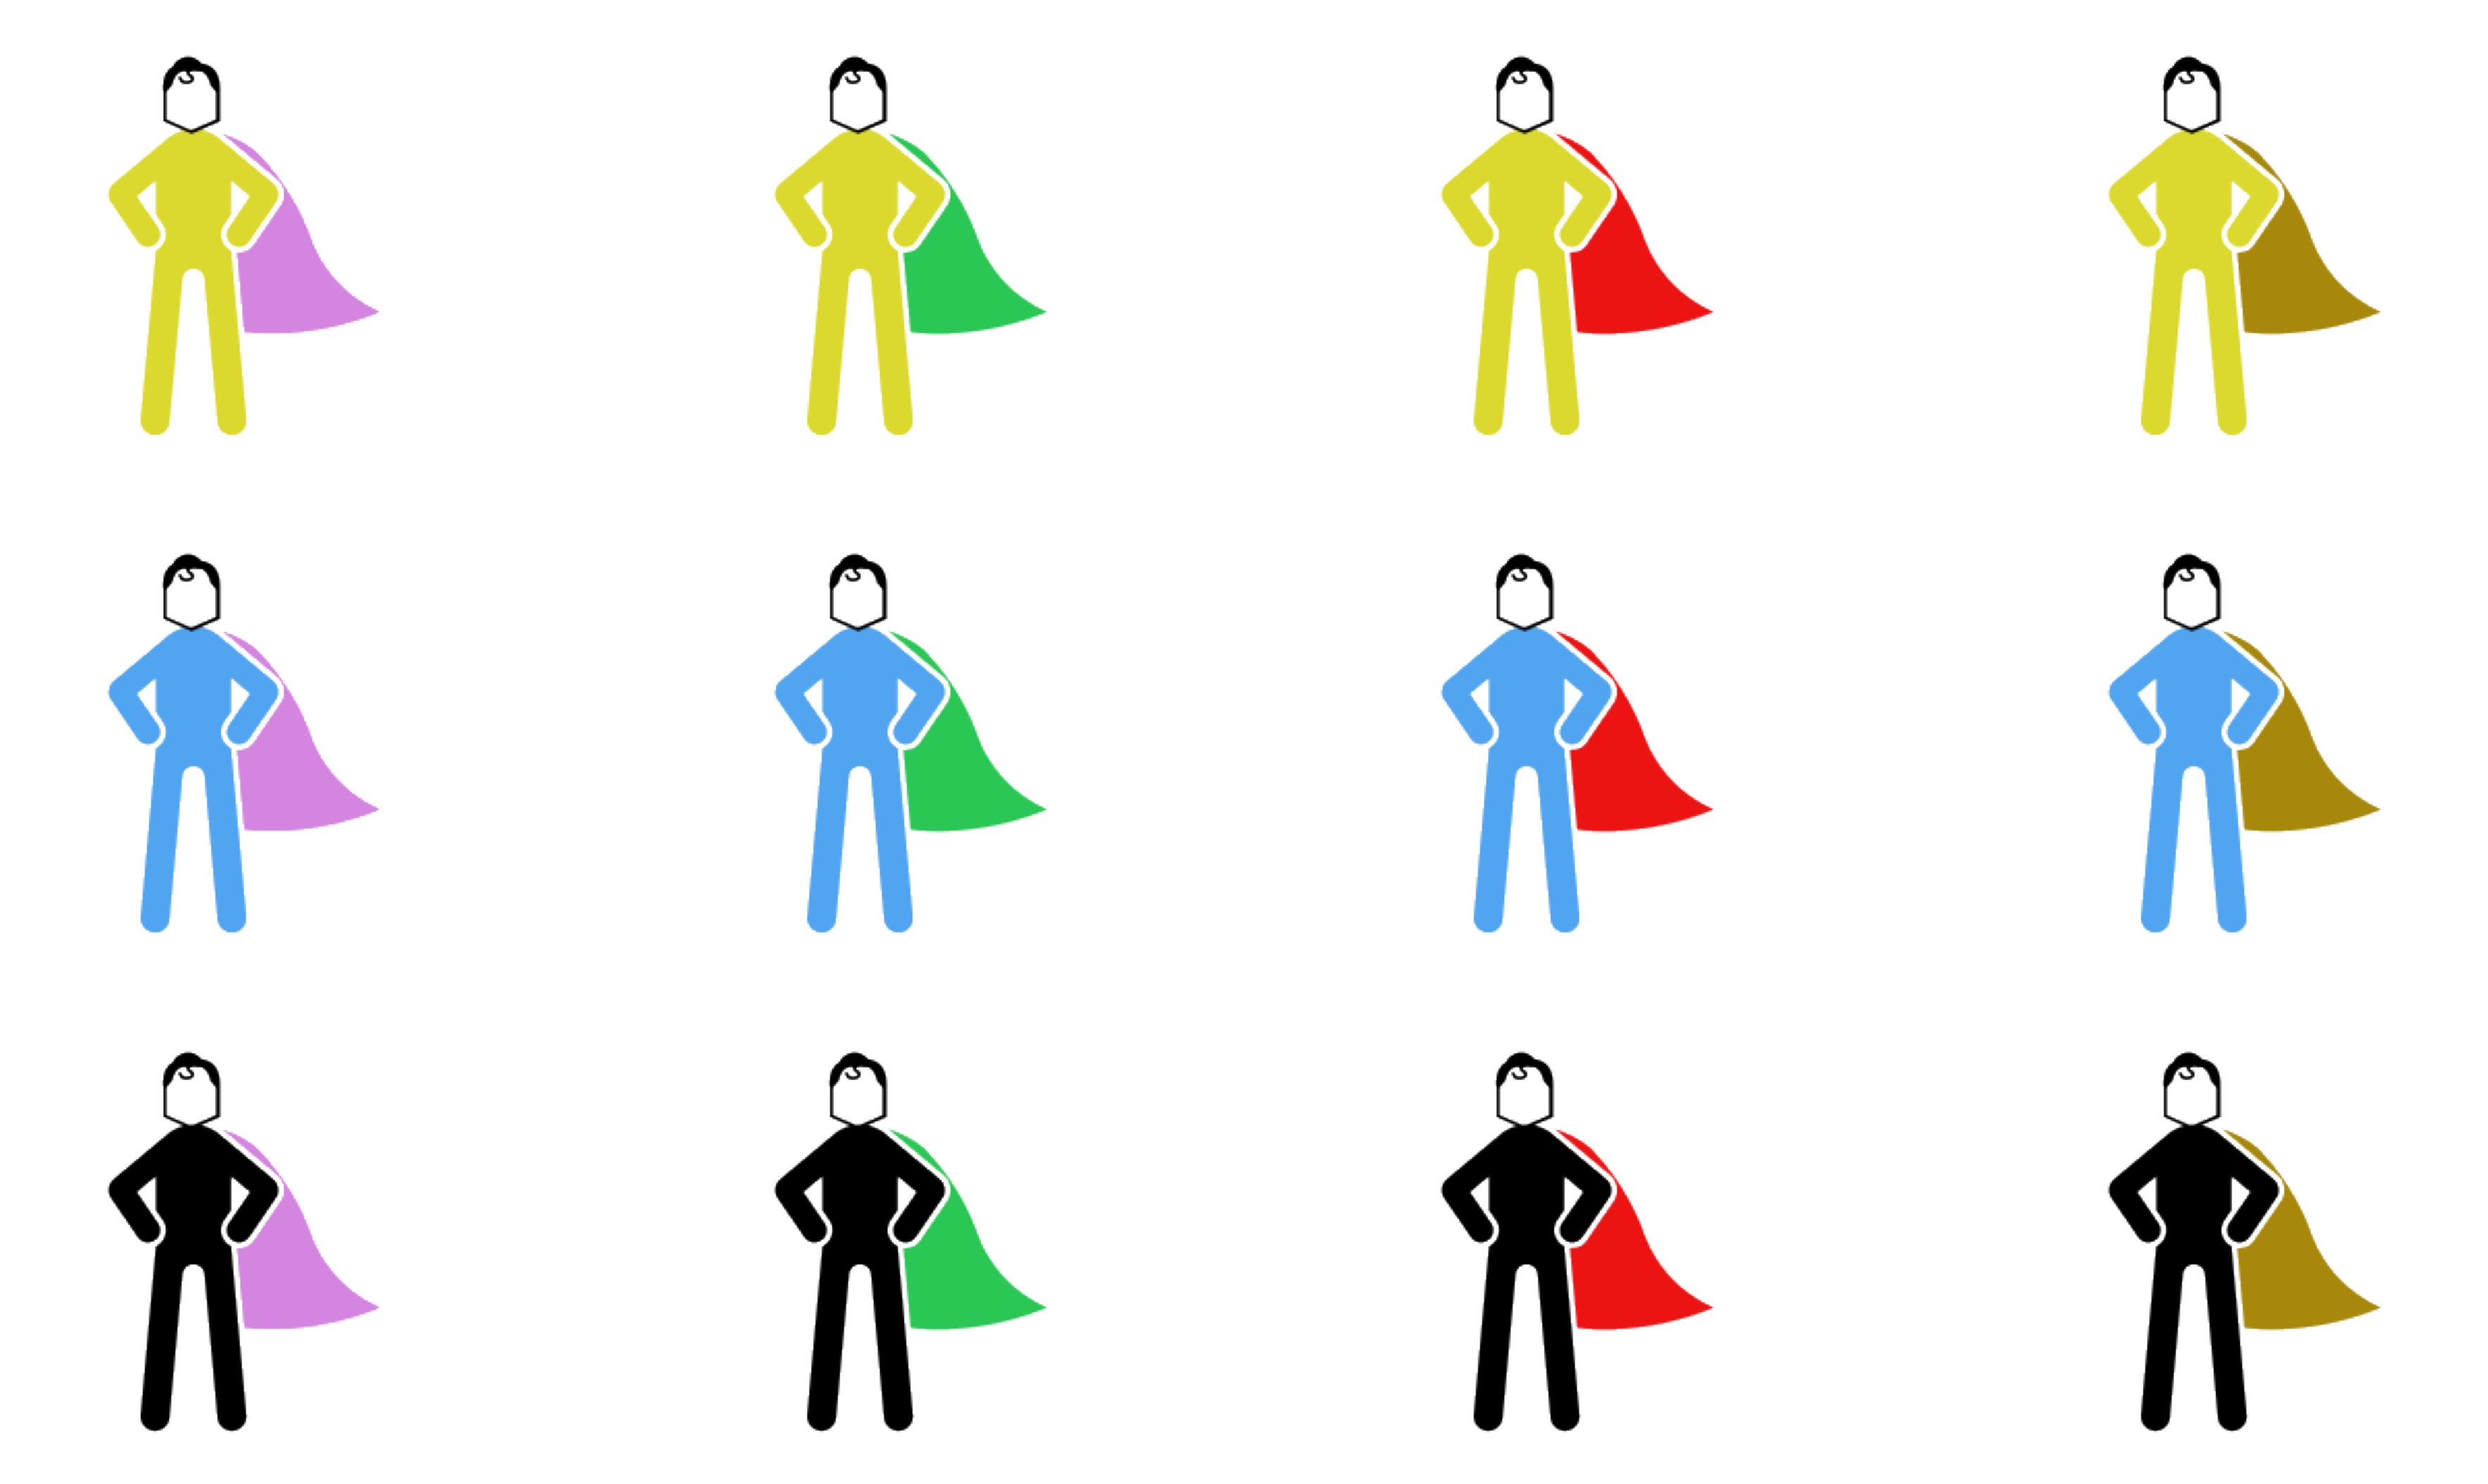

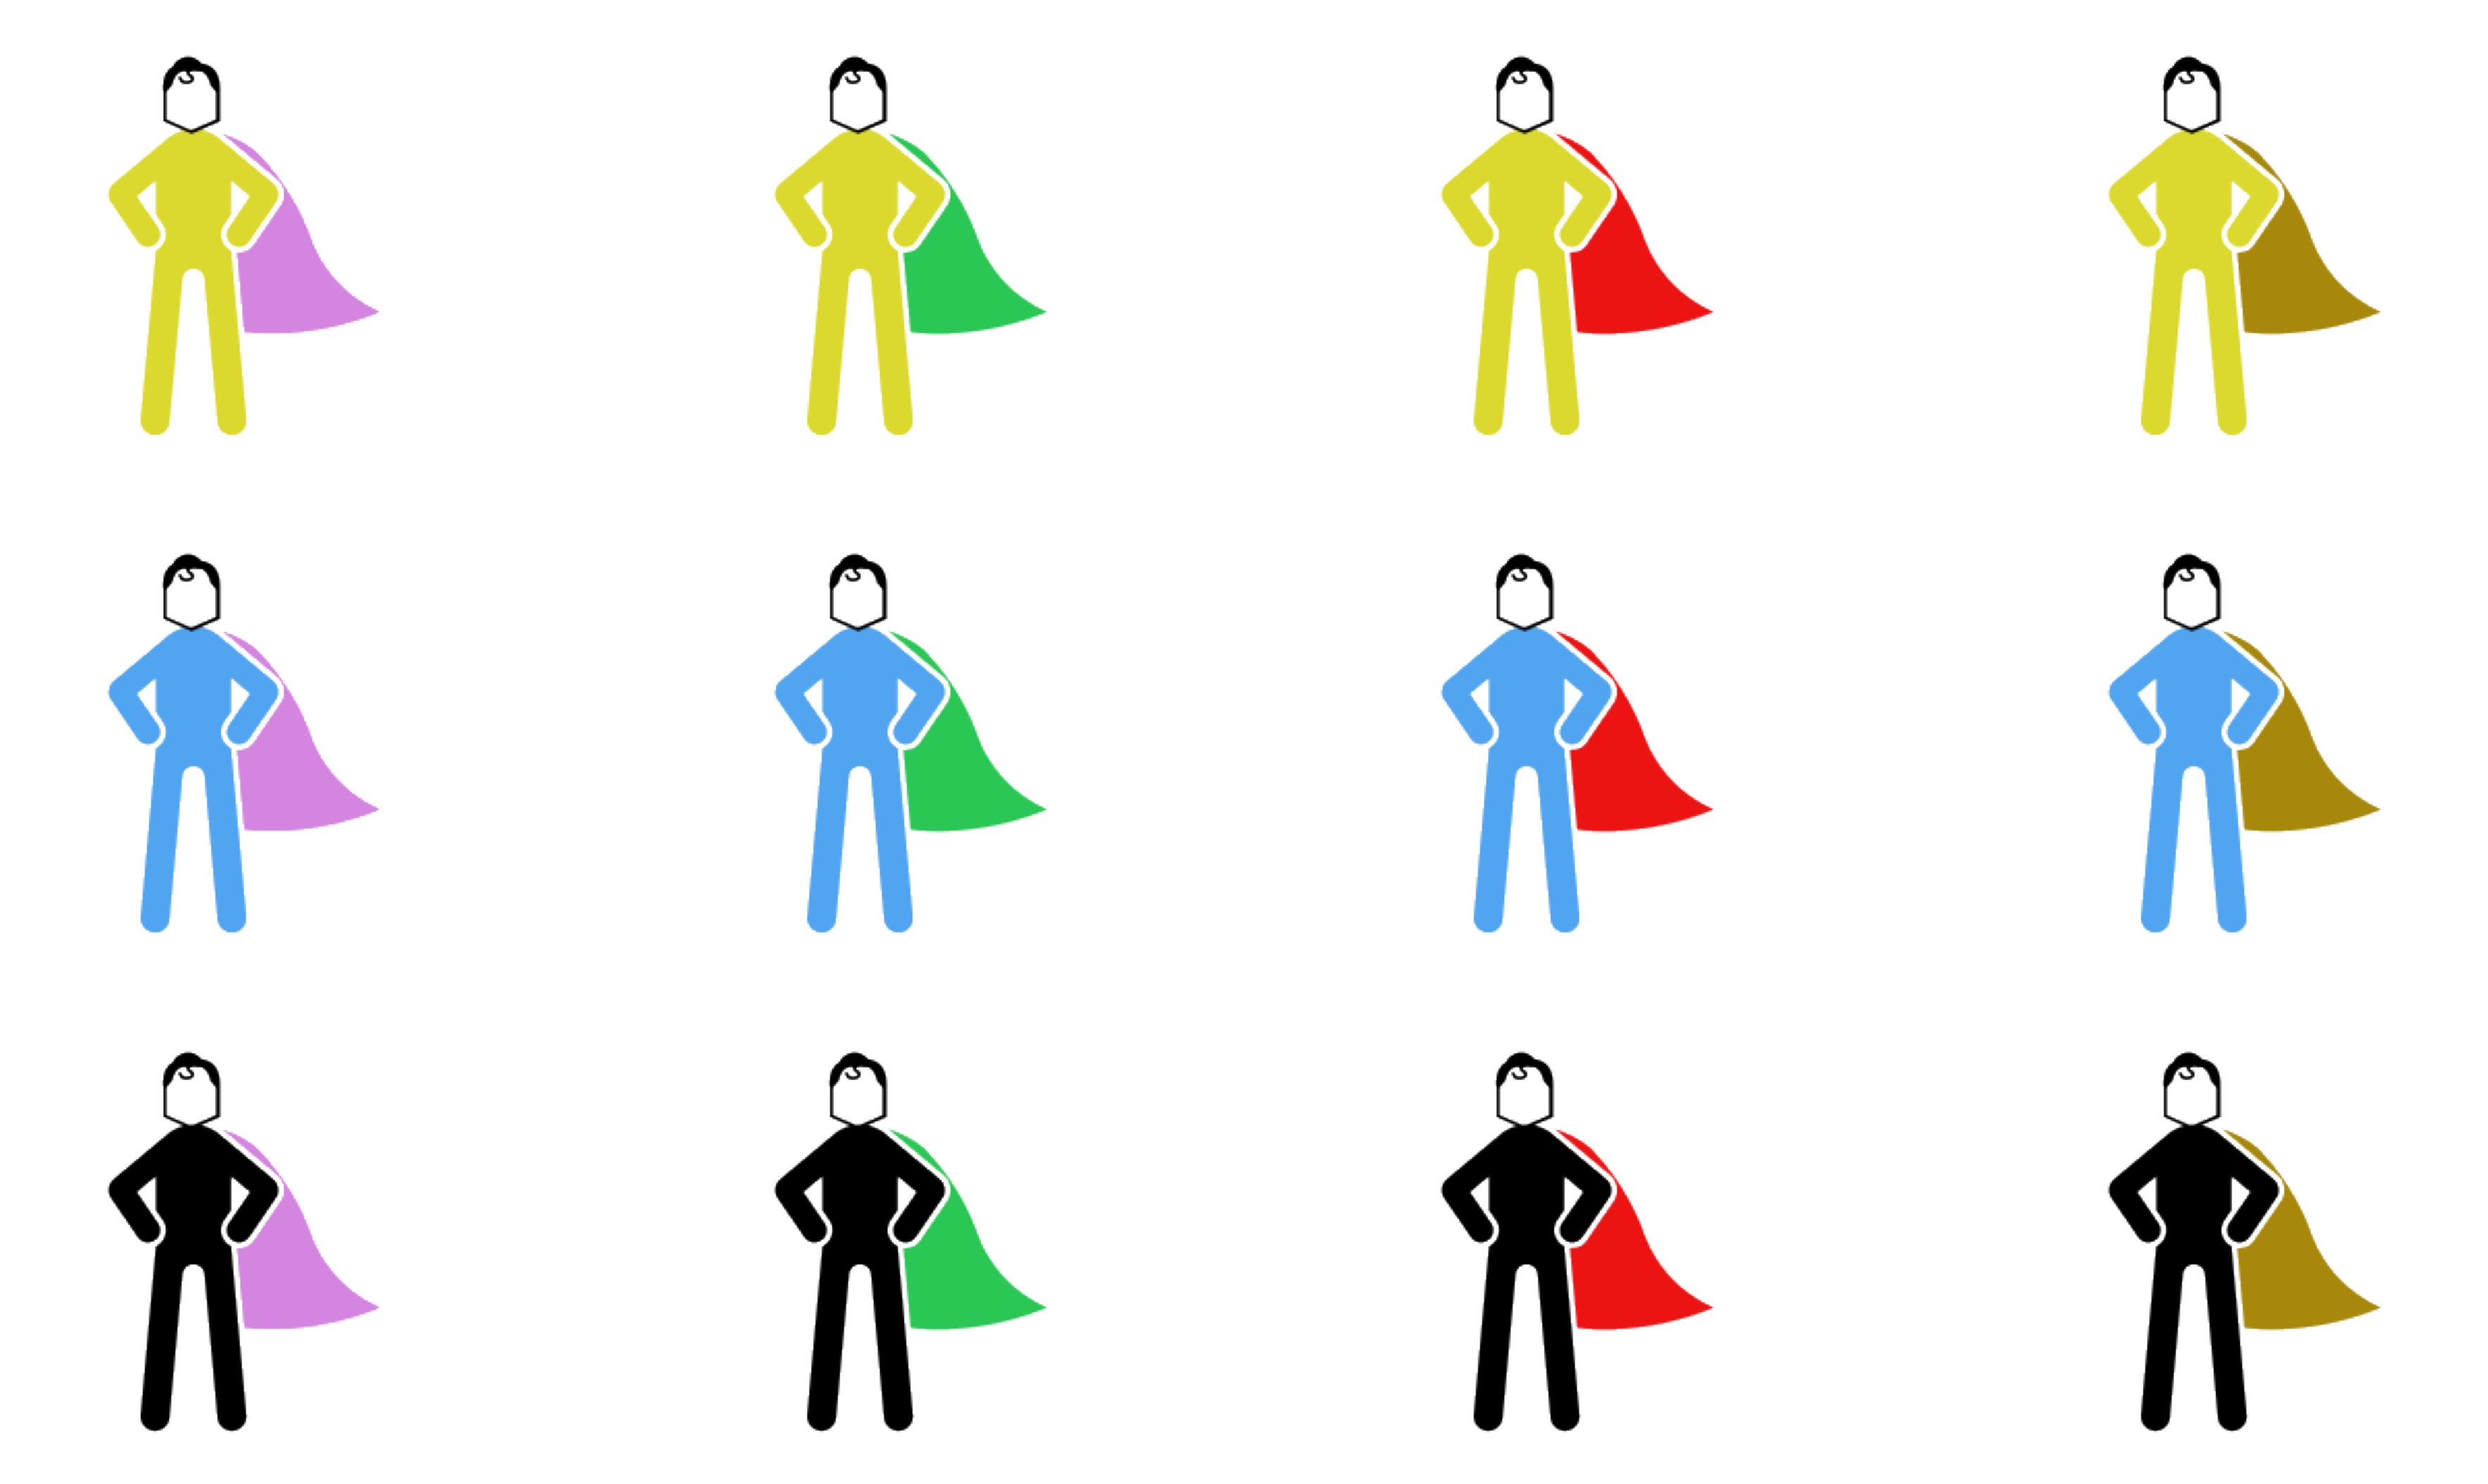

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.style.use('sds.mplstyle')

from myst_nb import glue

cloak = ['pink', 'green', 'red', 'brown']
costume = ['yellow', 'blue', 'black']

fig, ax = plt.subplots(len(costume), len(cloak), figsize=(9, 5))

for y, cost_col in enumerate(costume):
    for x, cloak_col in enumerate(cloak):
        img = mpimg.imread(f'img/sh-{cost_col}-{cloak_col}.png')
        ax[y][x].imshow(img)
        ax[y][x].axis('off')
plt.show()

glue("sh-combinations", fig, display=True)

```{glue:figure} sh-combinations
:figwidth: 100%
:name: "sh-combinations"

Una semplice illustrazione del principio fondamentale del calcolo combinatorio:
avendo quattro opzioni possibili per una prima scelta e tre opzioni per una
seconda scelta, si hanno dodici scelte combinate in tutto.
```

Generalizzando questo ragionamento si arriva al cosiddetto
_principio fondamentale del calcolo combinatorio_: se ci sono $s_1$ modi per
operare una scelta e, per ciascuno di essi, ci sono $s_2$ modi per operare
una seconda scelta e, per ciascuno di essi ci sono $s_3$ modi per operare una
terza scelta e così via fino a $s_t$ modi per operare la $t$-esima scelta,
allora il numero delle sequenze di possibili scelte è pari a

$$s_1 \cdot \ldots \cdot s_t = \prod_{i=1}^t s_i.$$

Osserviamo che questo risultato corrisponde a calcolare il numero delle
foglie di un albero di profondità $t$ il cui primo livello ha $s_1$ nodi,
ciascuno dei quali ha $s_2$ figli, ciascuno dei quali ha $s_3$ figli e così
via, come evidenziato nella {numref}`tree`.

In [2]:
import graphviz
import numpy as np

cap_colors = ['pink', 'green', 'red', 'brown']
costume_colors = ['black', 'blue', 'yellow']

tree = '''digraph { layout="neato" bgcolor="#00000000"
                    s[pos="0,0!" label="?"] \n'''

cap_rho = 1.3
cap_theta = np.linspace(0, np.pi, len(cap_colors))
cap_pos = np.array((cap_rho * np.cos(cap_theta),
                    cap_rho * np.sin(cap_theta))).T

costume_rho = 1
theta_diff = np.pi/2 /(len(costume_colors)+1)
theta_start = 0
theta_end = 2 * np.pi/6
theta_gap = (len(costume_colors) + 1) / len(costume_colors) * np.pi/6

for cap_color, (x, y) in zip(cap_colors, cap_pos):
    tree += f'cap_{cap_color}[pos="{x:.2f},{y:.2f}!" ' + \
            f'image="./img/{cap_color}-cap.png" label="", ' + \
            f'style="invisible" ' +\
            f'width=.6 height=.6 fixedsize="true"]\n'
    tree += f's -> cap_{cap_color};'



    costume_theta = np.linspace(theta_start, theta_end, len(costume_colors))
    costume_pos = np.array((costume_rho * np.cos(costume_theta),
                            costume_rho * np.sin(costume_theta))).T
    theta_start += theta_gap
    theta_end += theta_gap

    for costume_color, (x_delta, y_delta) in zip(costume_colors, costume_pos):
        tree += f'cap_{cap_color}_costume_{costume_color}' +\
                f'[pos="{x+x_delta:.2f},{y+y_delta:.2f}!" ' +\
                f'image="./img/sh-{costume_color}-{cap_color}.png" ' + \
                f'label="", ' + \
                f'style="invisible" width=.6 height=.6 fixedsize="true"]\n'
        tree += f'cap_{cap_color} -> cap_{cap_color}_costume_{costume_color};'


tree += '}'


graph = graphviz.Source(tree, format="png")
graph.render('tree')

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

```{figure} tree.png
:figwidth: 100%
:name: "tree"

L'albero che corrisponde alle scelte relative all'esempio illustrato nella
{numref}`sh-combinations`.
```

È importante notare come l'applicazione del principio fondamentale del
calcolo combinatorio prescinda dal tipo degli oggetti considerati, siano essi
mantelli, costumi, verdure, strumenti finanziari o altro. Se nell'esempio
precedente avessimo dovuto abbinare tre colori a quattro modelli di automobile
avremmo ottenuto lo stesso risultato numerico. In altre parole, i risultati
che si ottengono applicando le regole del calcolo combinatorio prescindono
dalla _natura_ degli oggetti, bensì dipendono solamente dalla loro numerosità
ed eventualmente dal numero di posti da tenere in considerazione. Si parla
infatti, ad esempio, delle _permutazioni_ di $n$ oggetti o delle
_combinazioni_ di $n$ oggetti in $k$ posti. Nei paragrafi che seguono, in
ogni caso, faremo spesso riferimento a oggetti specifici, per esemplificare
i concetti che verranno man mano esposti.